<a href="https://colab.research.google.com/github/lohithslohiths110405-ui/DATA_MINING/blob/main/DM_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
 import pandas as pd

In [3]:
import numpy as np
from google.colab import files
fie=files.upload()

Saving career_preferences_110_dataset.xlsx to career_preferences_110_dataset.xlsx


In [4]:
df=pd.read_excel("career_preferences_110_dataset.xlsx")

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 400)

In [6]:
print(df.head())

            Timestamp                  Full Name  Age Gender Education Qualification Specialization CGPA / Percentage (UG)                                   Skills Preferred Company Preferred Work Type     Career Goal
0   8/5/2026 10:53:33                      Manoj   22   Male            Data Science            NaN                    NaN                                      NaN               NaN                 NaN             NaN
1  8/11/2026 10:22:10                      Akash   22   Male                  B.Tech   Data Science                     90  SQL, Python, Power BI, Java, Deep Le...            Google              Office    Data Analyst
2  8/11/2026 10:23:30  Sunil Dundappa Kankanwadi   23   Male                     MCA        AI & ML                   81.8  SQL, Python, Machine Learning, Commu...               NaN              Office  AI/ML Engineer
3  8/11/2026 10:25:29                     Rakesh   23   Male                  M.Tech        AI & ML                     78     S

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Timestamp                110 non-null    object
 1   Full Name                110 non-null    object
 2   Age                      110 non-null    int64 
 3   Gender                   110 non-null    object
 4   Education Qualification  110 non-null    object
 5   Specialization           109 non-null    object
 6   CGPA / Percentage (UG)   108 non-null    object
 7   Skills                   109 non-null    object
 8   Preferred Company        102 non-null    object
 9   Preferred Work Type      109 non-null    object
 10  Career Goal              109 non-null    object
dtypes: int64(1), object(10)
memory usage: 9.6+ KB
None


In [8]:
print(df.isnull().sum())

Timestamp                  0
Full Name                  0
Age                        0
Gender                     0
Education Qualification    0
Specialization             1
CGPA / Percentage (UG)     2
Skills                     1
Preferred Company          8
Preferred Work Type        1
Career Goal                1
dtype: int64


In [9]:
df['Preferred Company']=df['Preferred Company'].fillna(df['Preferred Company'].mode()[0]);
df['Specialization']=df['Specialization'].fillna(df['Specialization'].mode()[0]);
df['CGPA / Percentage (UG)']=df['CGPA / Percentage (UG)'].fillna(df['CGPA / Percentage (UG)'].mode()[0]);
df['Skills']=df['Skills'].fillna(df['Skills'].mode()[0]);
df['Preferred Work Type']=df['Preferred Work Type'].fillna(df['Preferred Work Type'].mode()[0]);
df['Career Goal']=df['Career Goal'].fillna(df['Career Goal'].mode()[0]);

In [10]:
print(df.columns)

Index(['Timestamp', 'Full Name', 'Age', 'Gender', 'Education Qualification', 'Specialization', 'CGPA / Percentage (UG)', 'Skills', 'Preferred Company', 'Preferred Work Type', 'Career Goal'], dtype='object')


In [11]:
df=df.drop(columns=["Timestamp","Full Name"],axis=1)

In [12]:
print(df.columns)

Index(['Age', 'Gender', 'Education Qualification', 'Specialization', 'CGPA / Percentage (UG)', 'Skills', 'Preferred Company', 'Preferred Work Type', 'Career Goal'], dtype='object')


In [13]:
df=df.drop(columns=["Age","Gender","CGPA / Percentage (UG)"],axis=1)

In [14]:
print(df.isnull().sum())

Education Qualification    0
Specialization             0
Skills                     0
Preferred Company          0
Preferred Work Type        0
Career Goal                0
dtype: int64


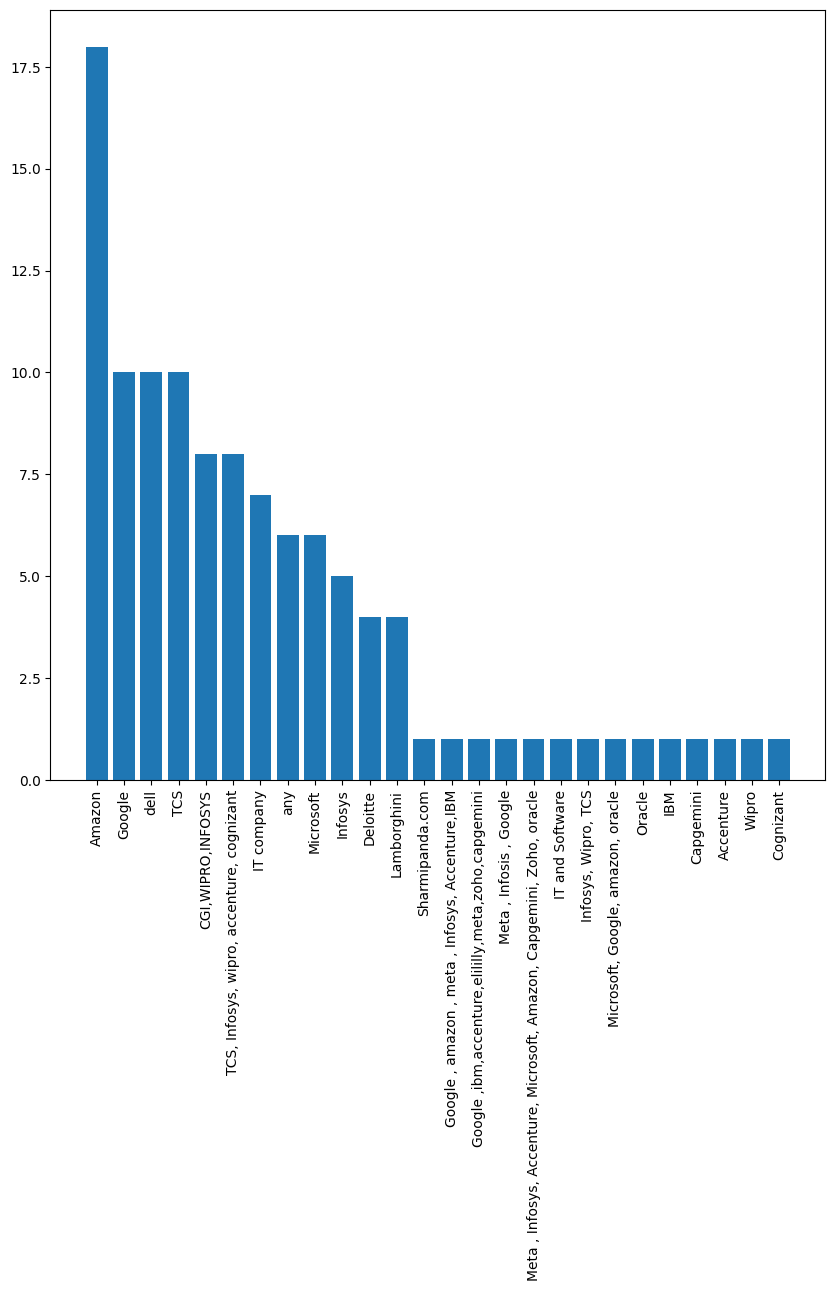

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.bar(x=df['Preferred Company'].unique(),height=df['Preferred Company'].value_counts())
plt.xticks(rotation=90)
plt.show()


In [16]:
print(df.Skills[0])

SQL, Python, Java, HTML/CSS, Communication


In [17]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
skills = df["Skills"].str.split(",")
skills = mlb.fit_transform(skills)
skills = pd.DataFrame(skills,columns=mlb.classes_)
df=pd.concat([df,skills],axis=1)

In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Education Qualification               110 non-null    object
 1   Specialization                        110 non-null    object
 2   Skills                                110 non-null    object
 3   Preferred Company                     110 non-null    object
 4   Preferred Work Type                   110 non-null    object
 5   Career Goal                           110 non-null    object
 6    API KEYS                             110 non-null    int64 
 7    C++                                  110 non-null    int64 
 8    Communication                        110 non-null    int64 
 9    Communication skills                 110 non-null    int64 
 10   Deep Learning                        110 non-null    int64 
 11   HTML/CSS                       

In [19]:
print(df)

    Education Qualification Specialization                                   Skills Preferred Company Preferred Work Type     Career Goal   API KEYS   C++   Communication   Communication skills   Deep Learning   HTML/CSS   Java   Machine Learning   Power BI   Python   RAG   c#  Python  SQL  Why should i tell you ? Its a secret  why should i tell you?? Its a secret
0              Data Science        AI & ML  SQL, Python, Java, HTML/CSS, Communi...            Amazon              Office  AI/ML Engineer          0     0               1                      0               0          1      1                  0          0        1     0    0       0    1                                     0                                     0
1                    B.Tech   Data Science  SQL, Python, Power BI, Java, Deep Le...            Google              Office    Data Analyst          0     0               0                      0               1          0      1                  0          1        1

In [20]:
print(df['Why should i tell you ? Its a secret'])

0      0
1      0
2      0
3      0
4      0
      ..
105    0
106    0
107    0
108    0
109    0
Name: Why should i tell you ? Its a secret, Length: 110, dtype: int64


In [21]:
print(df.loc[
    (df['Why should i tell you ? Its a secret'] == 1) |
    (df['why should i tell you?? Its a secret'] == 1)
])

   Education Qualification Specialization                                Skills Preferred Company Preferred Work Type Career Goal   API KEYS   C++   Communication   Communication skills   Deep Learning   HTML/CSS   Java   Machine Learning   Power BI   Python   RAG   c#  Python  SQL  Why should i tell you ? Its a secret  why should i tell you?? Its a secret
16                     MCA        AI & ML  why should i tell you?? Its a secret       Lamborghini              Remote      Others          0     0               0                      0               0          0      0                  0          0        0     0    0       0    0                                     0                                     1
18                     MCA        AI & ML  Why should i tell you ? Its a secret   Sharmipanda.com              Remote      Others          0     0               0                      0               0          0      0                  0          0        0     0    0       0    0

In [22]:

col1 = 'Why should i tell you ? Its a secret'
col2 = 'why should i tell you?? Its a secret'

df = df[
    (df[col1] == 0) &
    (df[col2] == 0)
]

In [23]:
df=df.drop(columns=['Why should i tell you ? Its a secret','why should i tell you?? Its a secret'])

In [24]:
print(df)

    Education Qualification Specialization                                   Skills Preferred Company Preferred Work Type     Career Goal   API KEYS   C++   Communication   Communication skills   Deep Learning   HTML/CSS   Java   Machine Learning   Power BI   Python   RAG   c#  Python  SQL
0              Data Science        AI & ML  SQL, Python, Java, HTML/CSS, Communi...            Amazon              Office  AI/ML Engineer          0     0               1                      0               0          1      1                  0          0        1     0    0       0    1
1                    B.Tech   Data Science  SQL, Python, Power BI, Java, Deep Le...            Google              Office    Data Analyst          0     0               0                      0               1          0      1                  0          1        1     0    0       0    1
2                       MCA        AI & ML  SQL, Python, Machine Learning, Commu...            Amazon              Office  AI/M

In [25]:
print(df.columns.to_list())

['Education Qualification', 'Specialization', 'Skills', 'Preferred Company', 'Preferred Work Type', 'Career Goal', ' API KEYS', ' C++', ' Communication', ' Communication skills', ' Deep Learning', ' HTML/CSS', ' Java', ' Machine Learning', ' Power BI', ' Python', ' RAG', ' c#', 'Python', 'SQL']


In [26]:
def clean_company(x):
    if pd.isna(x):
        return ""
    x = x.lower()
    companies = x.split(",")
    companies = [company.strip() for company in companies]
    return ",".join(companies)
df["Preferred Company"] = df["Preferred Company"].apply(clean_company)

In [27]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
comp = df["Preferred Company"].str.split(",")
comp = mlb.fit_transform(comp)
comp = pd.DataFrame(comp,columns=mlb.classes_)
df=pd.concat([df,comp],axis=1)

In [28]:
print(df.columns.to_list())

['Education Qualification', 'Specialization', 'Skills', 'Preferred Company', 'Preferred Work Type', 'Career Goal', ' API KEYS', ' C++', ' Communication', ' Communication skills', ' Deep Learning', ' HTML/CSS', ' Java', ' Machine Learning', ' Power BI', ' Python', ' RAG', ' c#', 'Python', 'SQL', 'accenture', 'amazon', 'any', 'capgemini', 'cgi', 'cognizant', 'dell', 'deloitte', 'elililly', 'google', 'ibm', 'infosis', 'infosys', 'it and software', 'it company', 'meta', 'microsoft', 'oracle', 'tcs', 'wipro', 'zoho']


In [29]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 110 entries, 0 to 18
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Education Qualification  108 non-null    object 
 1   Specialization           108 non-null    object 
 2   Skills                   108 non-null    object 
 3   Preferred Company        108 non-null    object 
 4   Preferred Work Type      108 non-null    object 
 5   Career Goal              108 non-null    object 
 6    API KEYS                108 non-null    float64
 7    C++                     108 non-null    float64
 8    Communication           108 non-null    float64
 9    Communication skills    108 non-null    float64
 10   Deep Learning           108 non-null    float64
 11   HTML/CSS                108 non-null    float64
 12   Java                    108 non-null    float64
 13   Machine Learning        108 non-null    float64
 14   Power BI                108 non

In [30]:
print(df.columns.to_list())

['Education Qualification', 'Specialization', 'Skills', 'Preferred Company', 'Preferred Work Type', 'Career Goal', ' API KEYS', ' C++', ' Communication', ' Communication skills', ' Deep Learning', ' HTML/CSS', ' Java', ' Machine Learning', ' Power BI', ' Python', ' RAG', ' c#', 'Python', 'SQL', 'accenture', 'amazon', 'any', 'capgemini', 'cgi', 'cognizant', 'dell', 'deloitte', 'elililly', 'google', 'ibm', 'infosis', 'infosys', 'it and software', 'it company', 'meta', 'microsoft', 'oracle', 'tcs', 'wipro', 'zoho']


In [31]:
col="any"
df=df[(df[col]==0)];
col="it and software"
df=df[(df[col]==0)];
col="it company"
df=df[(df[col]==0)];

In [32]:
df=df.drop(columns=["any","it and software",'it company'])

In [33]:
catcol=df.select_dtypes(include=object).columns

In [34]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in catcol:
  df[col]=le.fit_transform(df[col])

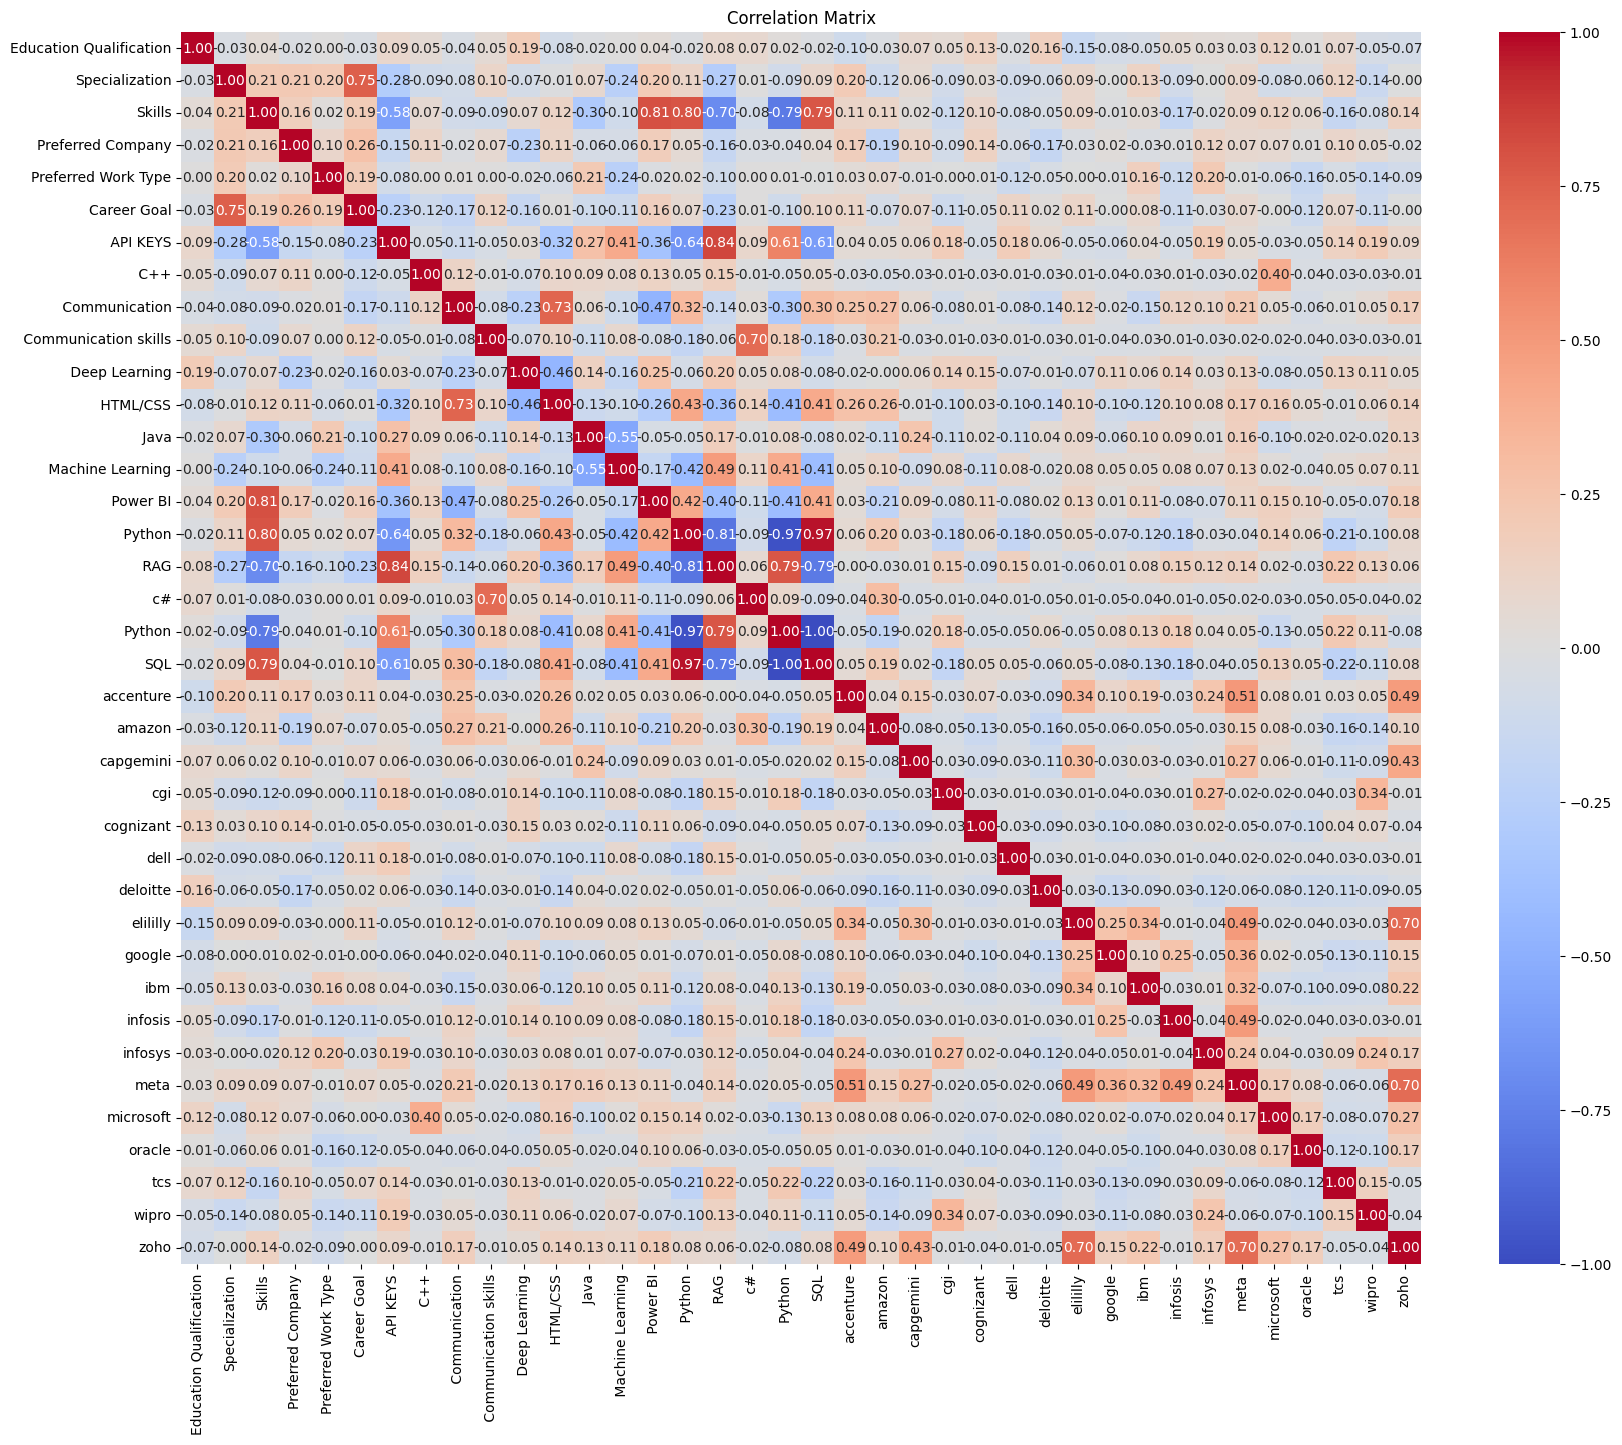

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot correlation heatmap
plt.figure(figsize=(20,16))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

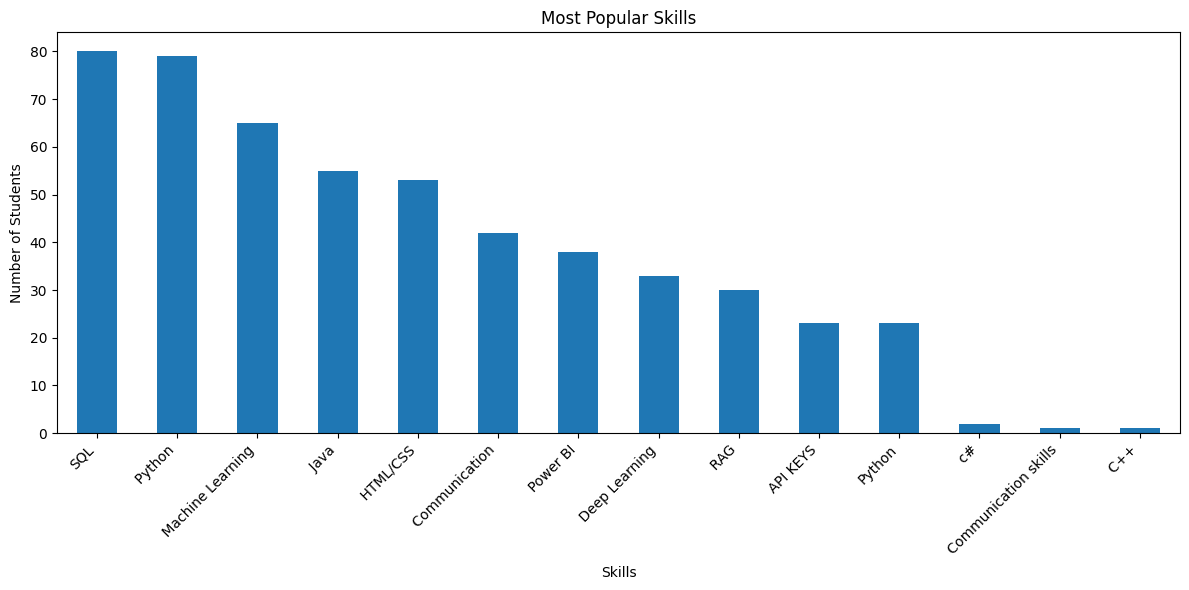

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# Skill columns
skill_columns = [
    ' API KEYS', ' C++', ' Communication', ' Communication skills',
    ' Deep Learning', ' HTML/CSS', ' Java', ' Machine Learning',
    ' Power BI', ' Python', ' RAG', ' c#', 'Python', 'SQL'
]

# Count how many students/users have each skill
skill_counts = df[skill_columns].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
skill_counts.plot(kind='bar')

plt.title("Most Popular Skills")
plt.xlabel("Skills")
plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

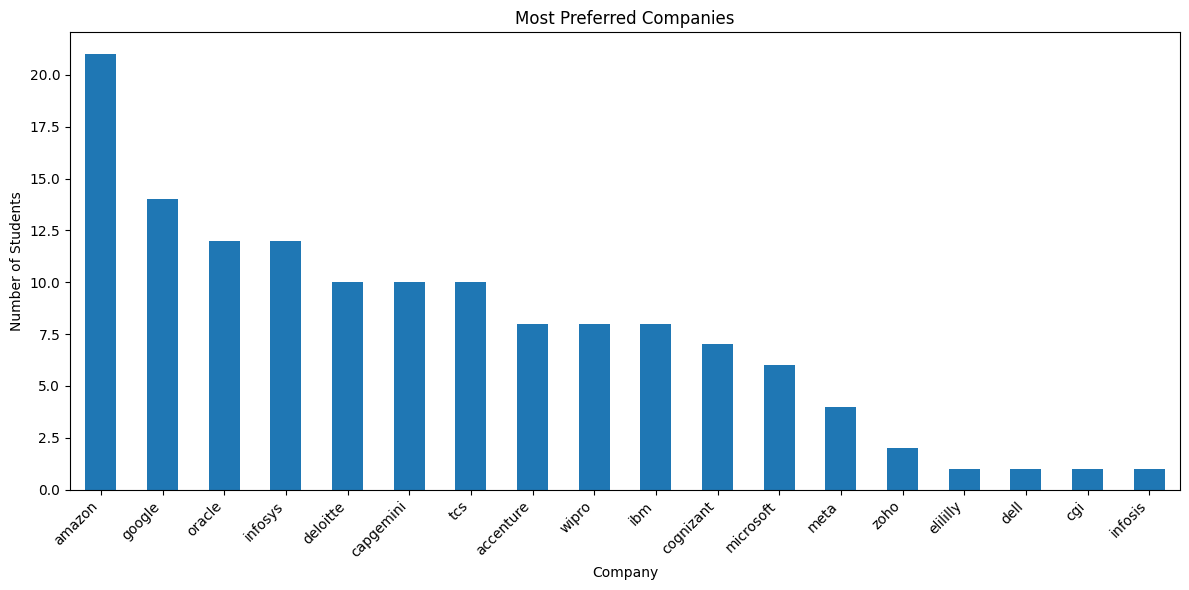

In [37]:
company_columns = [
    'accenture', 'amazon', 'capgemini', 'cgi', 'cognizant',
    'dell', 'deloitte', 'elililly', 'google', 'ibm',
    'infosis', 'infosys', 'meta', 'microsoft', 'oracle',
    'tcs', 'wipro', 'zoho'
]

company_counts = df[company_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
company_counts.plot(kind='bar')

plt.title("Most Preferred Companies")
plt.xlabel("Company")
plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [38]:
x=df.drop(columns="Career Goal")

In [39]:
y=df["Career Goal"]

In [40]:
print(df['Career Goal'])

0      0
1      2
2      0
3      3
4      2
      ..
105    0
106    2
107    0
16     5
18     5
Name: Career Goal, Length: 105, dtype: int64


In [41]:
print(y.shape)

(105,)


In [42]:
y = y.values.reshape(-1, 1)


In [43]:
from sklearn.model_selection import train_test_split

In [44]:
print(x.shape,y.shape)

(105, 37) (105, 1)


In [45]:
x,xt,y,yt=train_test_split(x,y,test_size=0.2,random_state=42)

In [46]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)


model.fit(x,y)
y_pred = model.predict(xt)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [50]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(yt, y_pred)

print("Accuracy:", accuracy)



Accuracy: 0.7142857142857143


In [53]:

print(classification_report(yt, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           2       0.58      0.88      0.70         8
           3       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         1

    accuracy                           0.71        21
   macro avg       0.37      0.47      0.41        21
weighted avg       0.56      0.71      0.63        21



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [54]:
# Copy one existing student row
new_student = x.iloc[[0]].copy()

# Change values
new_student["Education Qualification"] = 2
new_student["Specialization"] = 0
new_student["Skills"] = 5
new_student["Preferred Company"] = 7
new_student["Preferred Work Type"] = 1

# Predict
prediction = model.predict(new_student)

# Convert encoded prediction back to original career name
career = le.inverse_transform(prediction)

print("Predicted Career:", career[0])

# Show all career classes
print("Career Classes:", le.classes_)

Predicted Career: AI/ML Engineer
Career Classes: ['AI/ML Engineer' 'Cloud Engineer' 'Data Analyst' 'Data Scientist'
 'Web Developer' nan]


In [55]:
original_df = pd.read_excel("career_preferences_110_dataset.xlsx")

print(original_df["Career Goal"].value_counts())

Career Goal
AI/ML Engineer    41
Data Analyst      38
Data Scientist    25
Others             2
Cloud Engineer     2
Web Developer      1
Name: count, dtype: int64


In [56]:
from sklearn.preprocessing import LabelEncoder

career_encoder = LabelEncoder()

career_encoder.fit(original_df["Career Goal"].dropna())

print(career_encoder.classes_)

['AI/ML Engineer' 'Cloud Engineer' 'Data Analyst' 'Data Scientist'
 'Others' 'Web Developer']


In [57]:
prediction = model.predict(xt.iloc[[1]])

print("Predicted number:", prediction[0])
print("Predicted Career:", career_encoder.inverse_transform(prediction)[0])

Predicted number: 2
Predicted Career: Data Analyst
